In [23]:
from geostat_isoscapes_tools import utils, geostat_utils as gutils, plot_utils as putils
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import pandas as pd 

sns.set_style('dark')

In [24]:
countries= ['China']
itrace_data = gutils.get_itracedata_for_external_drift(delta18_da=True, include_snow=True, countries=countries) # possible args : res (by default it is the max number of days between two isoscapes), countries (None or list), buffer_km (float)

-> regular temporal resolution of 31.0 days


### **Detailed procedure for a single time step**

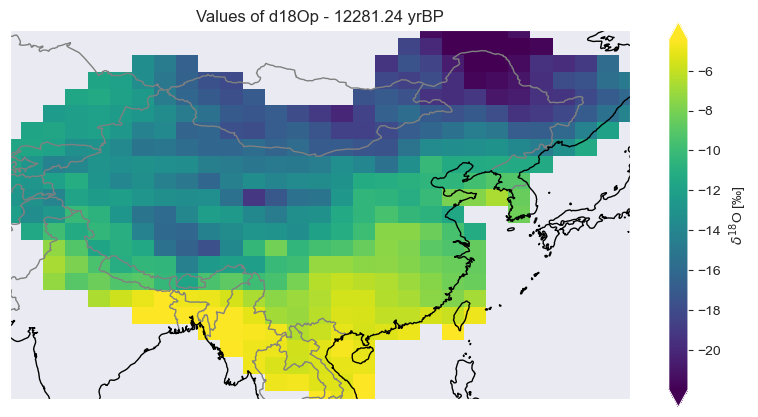

In [25]:
time=itrace_data['time'].values[-1398]

fig,ax = putils.plot_isoscape_latlon_platecarree(itrace_data.sel(time=time),time=f'{utils.get_yrBP_from_itrace_time(time):.2f} yrBP',countries_borders=True) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
plt.show() 
# Compute Variogram
# V = skg.Variogram(coords_proj, vals_s, n_lags=20, maxlag='median', model='spherical', use_nugget=True, normalize=False)
# ref_bins = V.bins
#
df=itrace_data.sel(time=time).to_dataframe(name='d18Op').reset_index().dropna(subset='d18Op') # type:ignore
df['x'], df['y'] = gutils.project_coords(df['lon'].values, df['lat'].values, epsg="EPSG:3857")


#### **Variogram on raw data**

First, let us see whether the data needs to be detrended or is already stationary. 

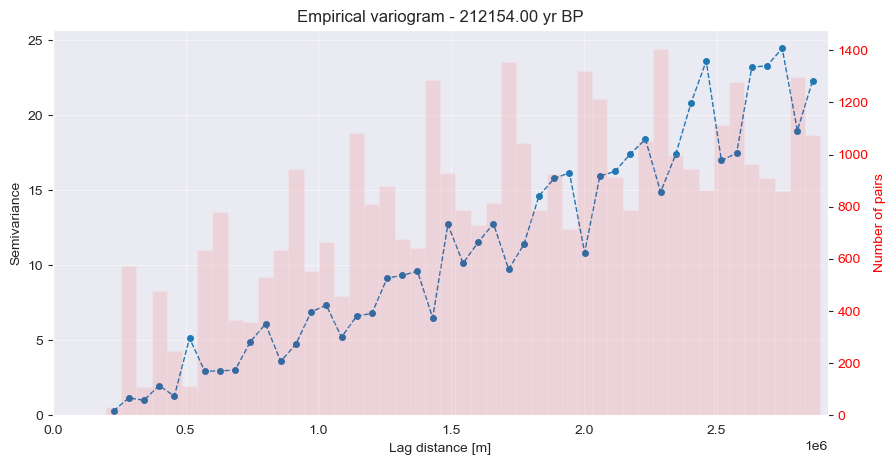

In [26]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend=None,
                                maxlag='median',
                                nlags=50,
                                return_Variogram_object=True,
                                #model='spherical+gaussian'
                                )
ref_bins = V.bins

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{time:.2f} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                #    plot_model=False,
                                                #    model_name=V._model_name,
                                                #    model_fct=V.fitted_model
                                                   ) #type:ignore
plt.show()

The variogram clearly has no sill, this means the data is non stationary and trends need to be removed.
We can try to fit a plane to the data in order to remove a linear drift, if any.

#### **Trend modelled as a simple plane**

r^2 of the trend model (plane) is: 0.7830108814710142


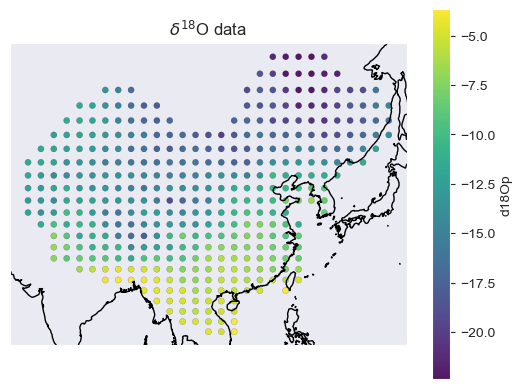

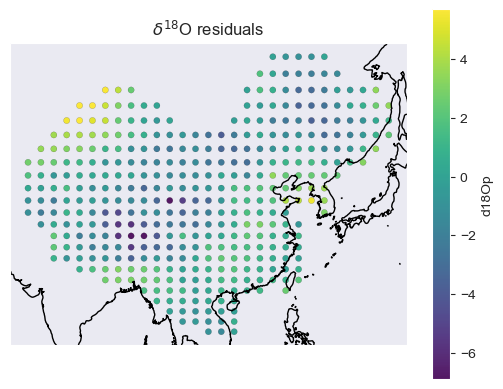

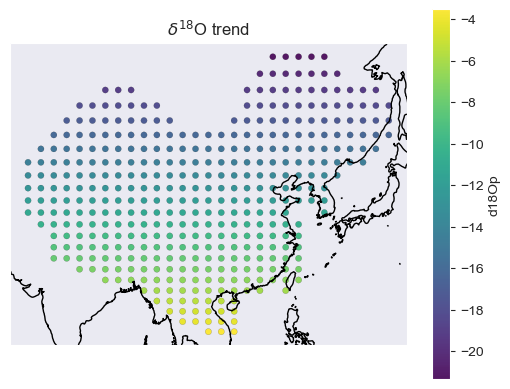

In [27]:
# Visualize the trend found by fitting a plane to the data :
vals = df['d18Op'].values
XY = np.column_stack((df['x'], df['y']))
resid = gutils.detrend_data_plane(XY,vals)

# Rsquare:
sst = np.sum((vals - np.mean(vals))**2)
ssr = np.sum(resid**2)
r2 = 1 - ssr / sst
print('r^2 of the trend model (plane) is:', r2)

fig,ax = putils.plot_projected_data(df[['x','y']].values,vals) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show()
 
fig,ax = putils.plot_projected_data(df[['x','y']].values,resid) # type:ignore
ax.set_title(r'$\delta^{18}$O residuals')
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
plt.show() 

fig,ax = putils.plot_projected_data(df[['x','y']].values,vals-resid) # type:ignore
ax.set_title(r'$\delta^{18}$O trend')
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
plt.show() 

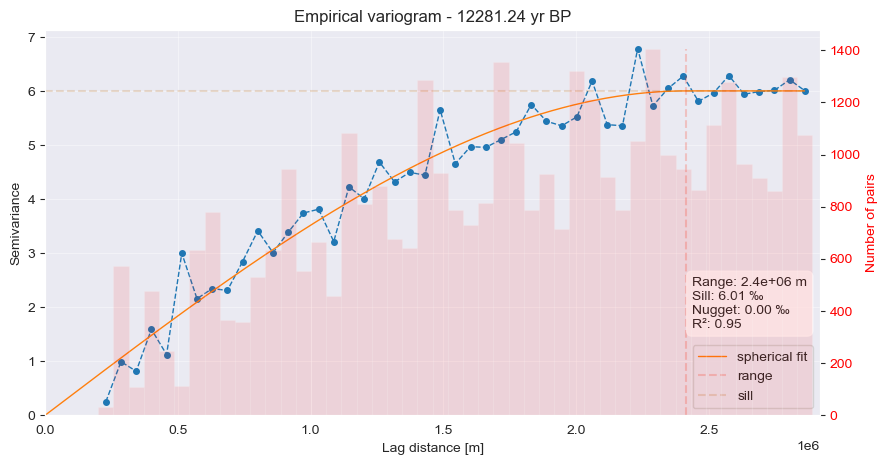

In [28]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='plane',
                                centers=ref_bins,
                                return_Variogram_object=True,
                                model='spherical'
                                )

parameters_dict= gutils.get_vario_parameters_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=True,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params=parameters_dict) #type:ignore
plt.show()

The linear plane fitted explained only <50% variance of the data, and unfortunately our data seems to have more complex trends than a linear drift, which is uninformed of the physics.

Physically, a known trend in delta18O values is the trend linked to the latitude : going away from tropical latitudes is correlate to a decrease in the delta 18O values.

Hence, we can try to fit and remove a multilinear trend model based on the predictor 'latitude' and 'latitude squared'

#### **Physically informed multilinear trend (multilinear regression)**

##### Latitude 

The predictors are  ['lat', 'lat2']
Total R^2 = 0.7839980669216047
Variance contributions: {'lat': np.float64(0.011384058276601803), 'lat2': np.float64(0.0004310168817328135)}
Regression coefficients: [ 2.27580926e+00 -3.55880685e-01 -9.49314066e-04]


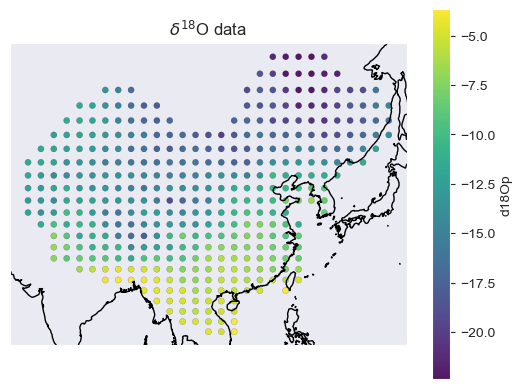

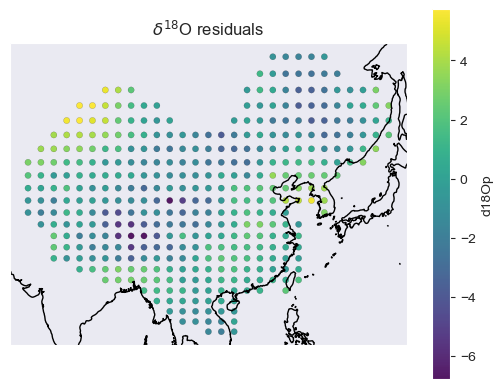

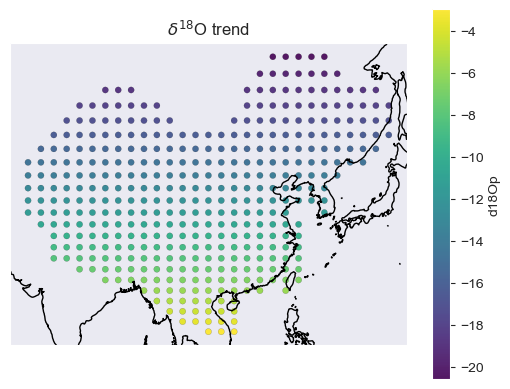

In [29]:
detrended_df, r2, contributions, beta = gutils.detrend_multilinear(df)
print("Total R^2 =", r2)
print("Variance contributions:", contributions)
print("Regression coefficients:", beta)

fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['d18Op'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['residual'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O residuals')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['trend'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O trend')
plt.show()

The predictors are  ['lat', 'lat2']
-> detrending with multilinear model, full R^2=0.784, contributions: {'lat': np.float64(0.011384058276601803), 'lat2': np.float64(0.0004310168817328135)}


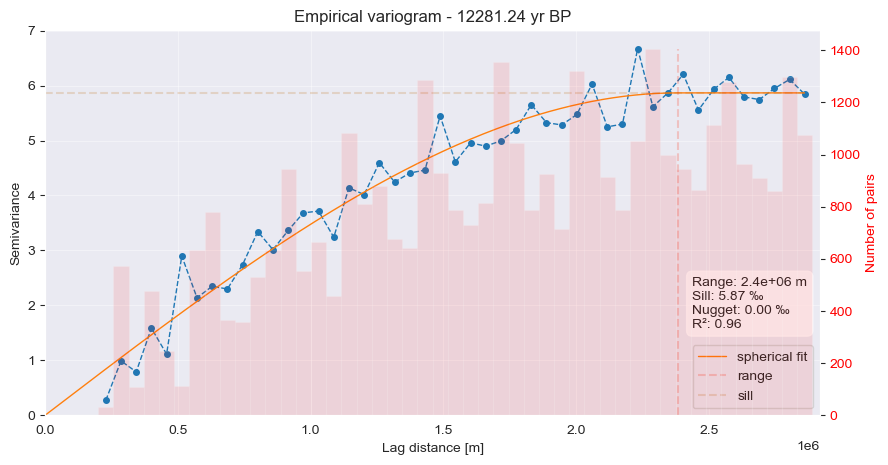

In [30]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='multilinear_lat',
                                centers=ref_bins,
                                return_Variogram_object=True,
                                model='spherical'
                                )

parameters_dict= gutils.get_vario_parameters_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=True,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params=parameters_dict) #type:ignore
plt.show()

This time, we explained up to 85% (depending on the time chosen) of the variance. Let us see whether other known trends can be retrieved in the data : elevation for instance.

##### Elevation

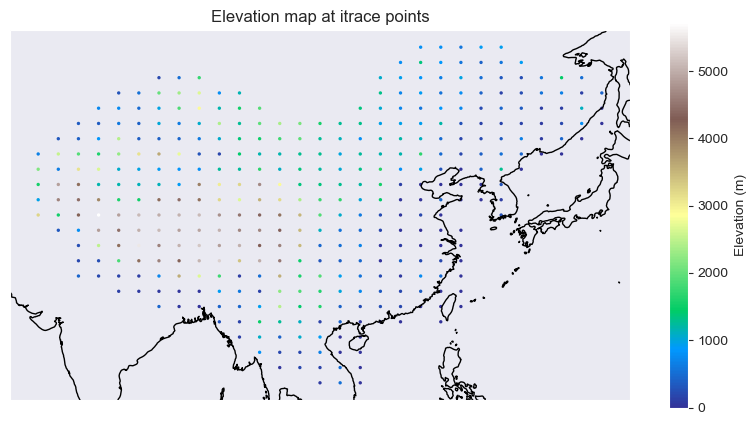

In [31]:
# Inerpolate (bilinear) a DEM at itrace points (ETOPO for instance)
df = gutils.interpolate_dem_at_latlon_points(df)
# now our df has a column 'elevation'
# plot elevation map 
fig,ax = putils.plot_elevation_map(df,countries_borders=False) # type:ignore
ax.set_title('Elevation map at itrace points')
plt.show()  

The predictors are  ['lat', 'lat2', 'elevation']
Total R^2 = 0.8360494559582061
Variance contributions: {'lat': np.float64(0.00030294470496196904), 'lat2': np.float64(0.010627975214783958), 'elevation': np.float64(0.05205138903660145)}
Regression coefficients: [-1.49632712e+00 -6.22272624e-02 -5.06808011e-03 -7.83935956e-04]


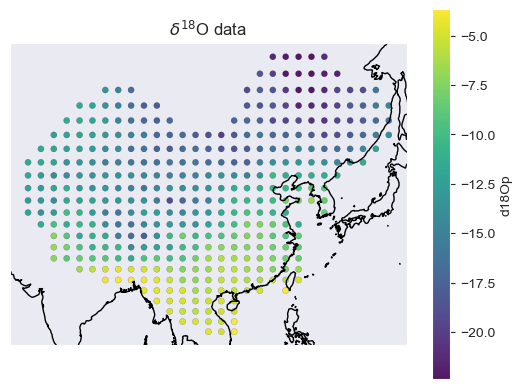

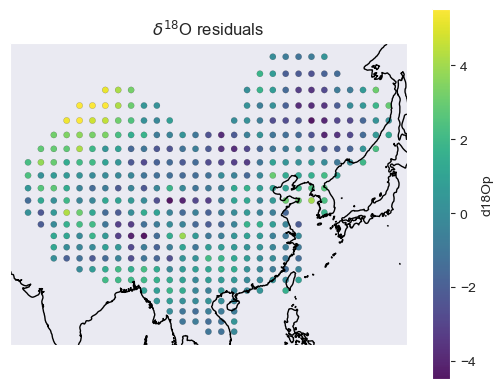

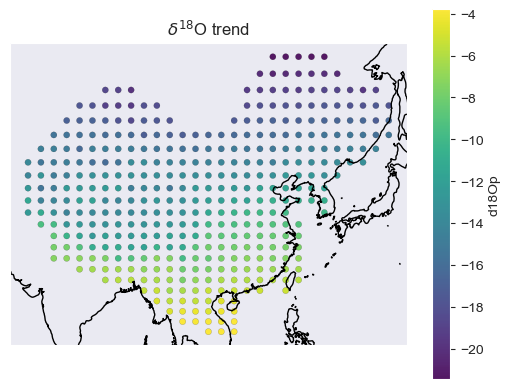

In [32]:
# Now let us fit our trend model including this feature
detrended_df, r2, contributions, beta = gutils.detrend_multilinear(df,include_elev=True,include_lat=True)
print("Total R^2 =", r2)
print("Variance contributions:", contributions)
print("Regression coefficients:", beta)

fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['d18Op'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['residual'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O residuals')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['trend'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O trend')
plt.show()

The predictors are  ['lat', 'lat2', 'elevation']
-> detrending with multilinear model, full R^2=0.836, contributions: {'lat': np.float64(0.00030294470496196904), 'lat2': np.float64(0.010627975214783958), 'elevation': np.float64(0.05205138903660145)}


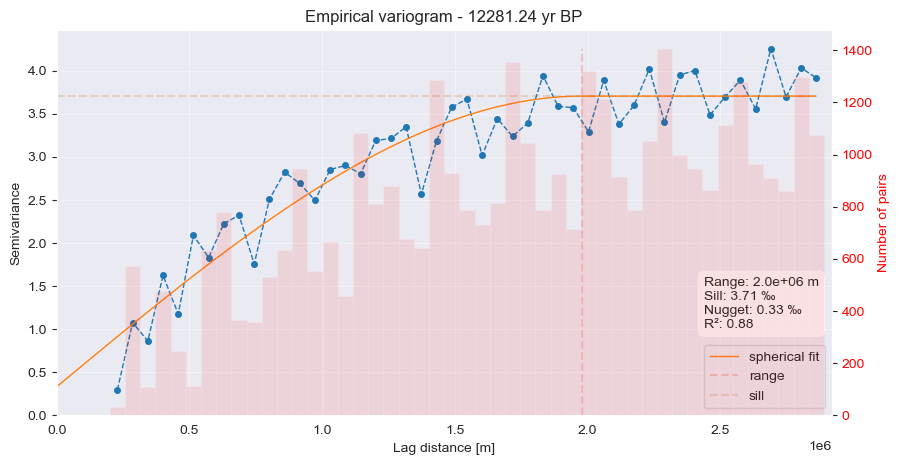

In [33]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='multilinear_elev_lat',
                                centers=ref_bins,
                                return_Variogram_object=True,
                                model='spherical'
                                )

parameters_dict= gutils.get_vario_parameters_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=True,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params=parameters_dict) #type:ignore
plt.show()

We clearly see the trend linked to altitude in the Himalayas or the Rocky mountains, and gained a few percents of variance explanation.

Now, let us finally introduce the distance to the coast as predictor in our multilinear trend model. This is supposed to enable to capture the continental effect : decrease in delta18O values as the distance to the coast increases. 

##### Distance to the coast

In [34]:
from shapely.geometry import Point
from shapely.ops import nearest_points
from pyproj import Geod
import geopandas as gpd


def compute_distance_to_coast(df, coast_shp_path):
    """
    Add geodesic distance to nearest coastline (in meters) to a dataframe 
    containing columns 'lat' and 'lon'.
    Inputs:
        df : pandas.DataFrame, it must contain 'lat' and 'lon' columns.
        coast_shp_path : str, the path to a coastline shapefile.
    Outputs:
        df : pandas.DataFrame, same dataframe as input but with an extra column 'dist_coast_m'.
    """
    if any(df['lon']>180):
        df['lon'] = utils.convert_lon_0_360_to_neg180_180(df['lon'].values)
    if any(df['lat']>90):
        df['lat'] = utils.convert_lat_0_180_to_neg90_90(df['lat'].values)
    
    coast = gpd.read_file(coast_shp_path).to_crs("EPSG:4326")

    geod = Geod(ellps="WGS84")

    distances = []
    for _, row in df.iterrows():
        pt = Point(row["lon"], row["lat"])
        # find actual nearest geometry, not just BB neighbors
        nearest_idx = coast.sindex.nearest(pt)[1]
        nearest_geom = coast.geometry.iloc[nearest_idx]

        # compute geodesic distance
        p1, p2 = nearest_points(pt, nearest_geom)
        _, _, dist = geod.inv(p1.iloc[0].x, p1.iloc[0].y, p2.iloc[0].x, p2.iloc[0].y) # type: ignore
        distances.append(dist)

    df["dist_coast_m"] = distances
    return df

df = compute_distance_to_coast(
    df,
    coast_shp_path="../data/shapefiles/ne_10m_coastline/ne_10m_coastline.shp"
)

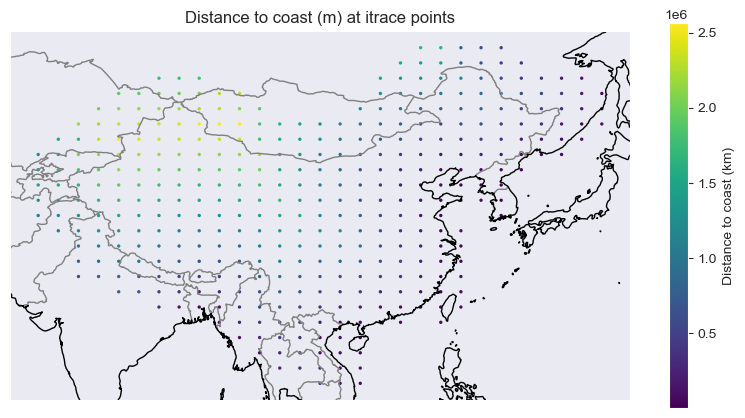

In [35]:
# df.loc[df['dist_coast_m']>2700000,'dist_coast_m']=pd.NA
fig,ax = putils.plot_dist_to_coast_map(df,countries_borders=True) # type:ignore
ax.set_title('Distance to coast (m) at itrace points')
plt.show()

The predictors are  ['lat', 'lat2', 'elevation', 'dist_coast_m']
Total R^2 = 0.8419016325593774
Variance contributions: {'lat': np.float64(0.0007849499309697249), 'lat2': np.float64(0.009587770144718042), 'elevation': np.float64(0.0572855031070513), 'dist_coast_m': np.float64(0.005852176601171321)}
Regression coefficients: [-8.58751702e-01 -1.01176542e-01 -4.82382013e-03 -9.03543649e-04
  6.46735361e-07]


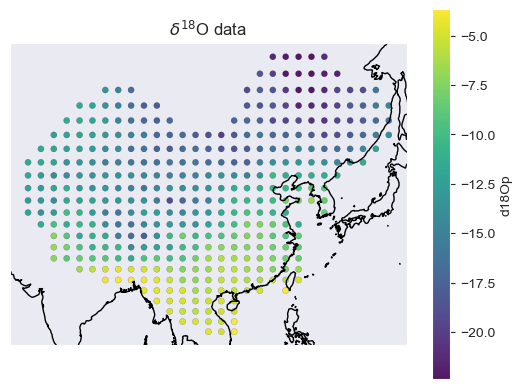

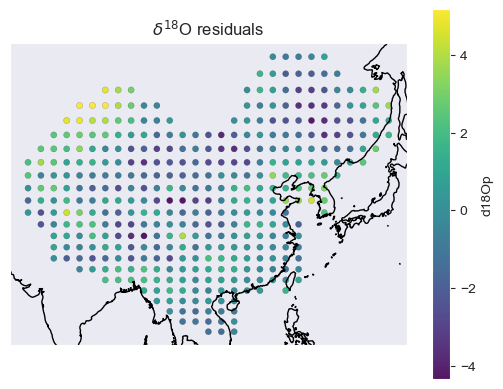

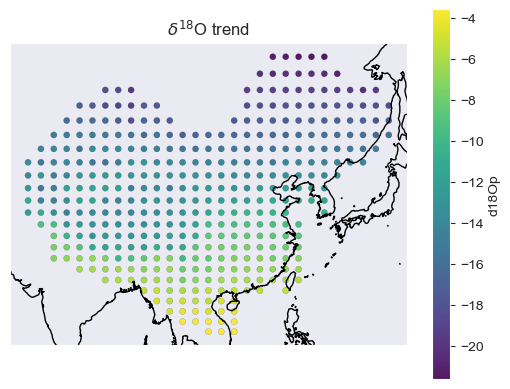

In [36]:
detrended_df, r2, contributions, beta = gutils.detrend_multilinear(df,include_elev=True,include_lat=True,include_dcoast=True,dist_col='dist_coast_m')
print("Total R^2 =", r2)
print("Variance contributions:", contributions)
print("Regression coefficients:", beta)

fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['d18Op'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['residual'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O residuals')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['trend'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O trend')
plt.show()

The predictors are  ['lat', 'lat2', 'elevation', 'dist_coast_m']
-> detrending with multilinear model, full R^2=0.842, contributions: {'lat': np.float64(0.0007849499309697249), 'lat2': np.float64(0.009587770144718042), 'elevation': np.float64(0.0572855031070513), 'dist_coast_m': np.float64(0.005852176601171321)}


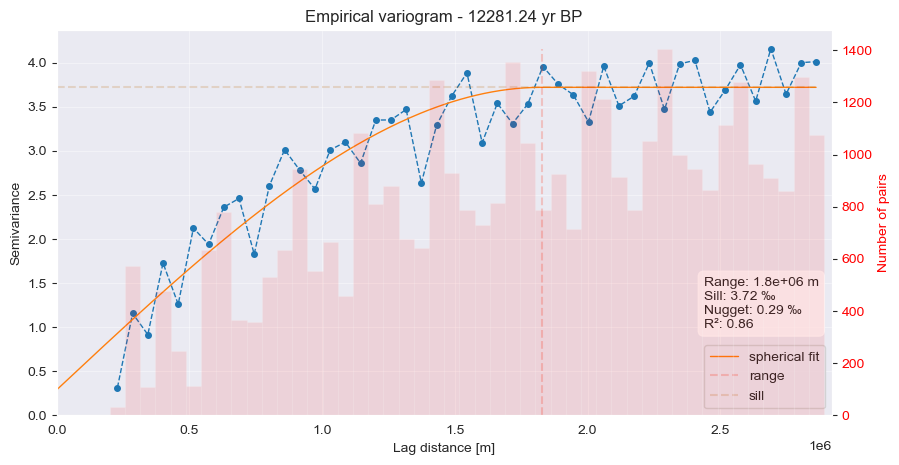

In [37]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='multilinear_elev_lat_dcoast',
                                centers=ref_bins,
                                return_Variogram_object=True,
                                model='spherical'
                                )
parameters_dict= gutils.get_vario_parameters_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=True,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params=parameters_dict) #type:ignore
plt.show()

##### Precipiation amount

Some of the unexplained variance may be explained by the monthly mean precipitation and monthly mean temperature at each location.

In [38]:
fn_itrace_rain = '../data/modern/iTrace/b.e13.Bi1850C5.f19_g16.12ka.itrace.ice_ghg_orb_wtr.05.clm2.h0.RAIN.800001-899912.nc'
fn_itrace_snow = '../data/modern/iTrace/b.e13.Bi1850C5.f19_g16.12ka.itrace.ice_ghg_orb_wtr.05.clm2.h0.SNOW.800001-899912.nc'
file_rain = utils.load_xarray_datarray(fn_itrace_rain)
file_snow = utils.load_xarray_datarray(fn_itrace_snow)
# file_rain.info()
# file_snow.info()
rain_da = file_rain.RAIN
snow_da = file_snow.SNOW
# total precip 
prect_da = rain_da + snow_da
# bin time to match itrace_da resolution
binned_prect_da = utils.bin_xrDataArray_time(prect_da,res=31)

binned_prect_da = binned_prect_da * 31 * 24 * 3600 # convert the flux (precipitation rate) to the monthly total 
# mask the countries defined earlier 
if countries is not None :
    binned_prect_da = utils.mask_country_shape(binned_prect_da, buffer_km = 500, country_names=countries)


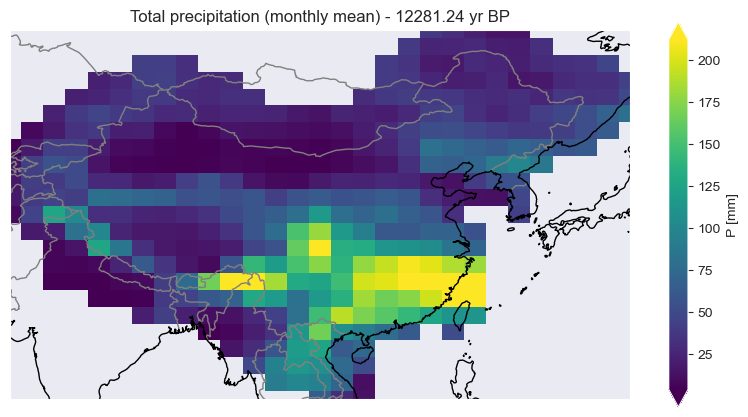

In [39]:
fig,ax = putils.plot_isoscape_latlon_platecarree(binned_prect_da.sel(time=time),time=f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',countries_borders=True,title='Total precipitation (monthly mean)',cbar_label='P [mm]') # type:ignore
plt.show() 
# Compute Variogram
# V = skg.Variogram(coords_proj, vals_s, n_lags=20, maxlag='median', model='spherical', use_nugget=True, normalize=False)
# ref_bins = V.bins
#
df_prect=binned_prect_da.sel(time=time).to_dataframe(name='prect').reset_index().dropna(subset='prect') # type:ignore
df_prect['lon']=utils.convert_lon_0_360_to_neg180_180(df_prect['lon'])

In [40]:
df = pd.merge(df,df_prect,how='left',on=['lon','lat','time'])

In [41]:
df

,lat,lon,time,d18Op,x,y,elevation,dist_coast_m,prect
0,14.210526,105.0,212154.0,-4.481494,1.168855e+07,1.598381e+06,79.702799,3.402564e+05,63.479794
1,14.210526,107.5,212154.0,-5.012333,1.196685e+07,1.598381e+06,529.466571,1.728347e+05,28.236462
2,14.210526,110.0,212154.0,-3.611505,1.224514e+07,1.598381e+06,0.000000,8.259635e+04,13.430428
3,16.105263,100.0,212154.0,-4.861236,1.113195e+07,1.816916e+06,39.829526,2.450342e+05,90.619385
4,16.105263,102.5,212154.0,-4.728496,1.141025e+07,1.816916e+06,179.375095,3.309935e+05,99.225815
...,...,...,...,...,...,...,...,...,...
385,55.894737,117.5,212154.0,-21.443008,1.308004e+07,7.537489e+06,801.895797,1.685742e+06,37.682800
386,55.894737,120.0,212154.0,-22.177935,1.335834e+07,7.537489e+06,782.888012,1.666268e+06,29.920792
387,55.894737,122.5,212154.0,-22.375525,1.363664e+07,7.537489e+06,562.061669,8.114356e+05,21.981638
388,55.894737,125.0,212154.0,-22.318363,1.391494e+07,7.537489e+06,899.530601,6.555673e+05,14.507800


The predictors are  ['lat', 'lat2', 'elevation', 'dist_coast_m', 'prect']
Total R^2 = 0.8422111516267163
Variance contributions: {'lat': np.float64(0.0008365878696878873), 'lat2': np.float64(0.009075781381371497), 'elevation': np.float64(0.05574311522060709), 'dist_coast_m': np.float64(0.006105760746201993), 'prect': np.float64(0.0003095190673389424)}
Regression coefficients: [-1.00567865e+00 -1.04603310e-01 -4.72417329e-03 -8.96415536e-04
  6.66274965e-07  1.75417700e-03]


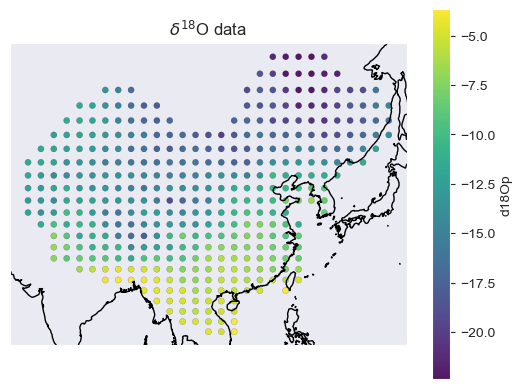

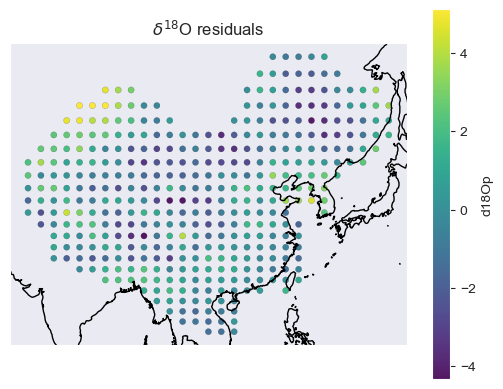

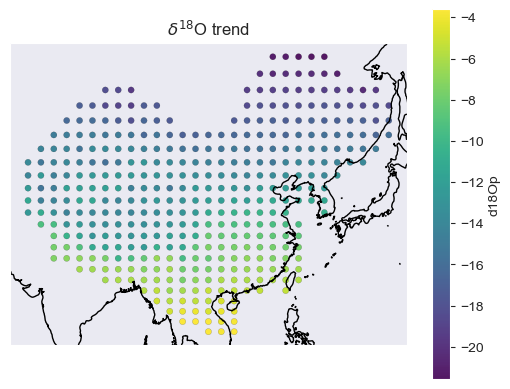

In [42]:
detrended_df, r2, contributions, beta = gutils.detrend_multilinear(df,
                                                                   include_elev=True,
                                                                   include_lat=True,
                                                                   include_dcoast=True,
                                                                   include_prect=True,
                                                                   dist_col='dist_coast_m')
print("Total R^2 =", r2)
print("Variance contributions:", contributions)
print("Regression coefficients:", beta)

fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['d18Op'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['residual'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O residuals')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['trend'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O trend')
plt.show()

The predictors are  ['lat', 'lat2', 'elevation', 'dist_coast_m', 'prect']
-> detrending with multilinear model, full R^2=0.842, contributions: {'lat': np.float64(0.0008365878696878873), 'lat2': np.float64(0.009075781381371497), 'elevation': np.float64(0.05574311522060709), 'dist_coast_m': np.float64(0.006105760746201993), 'prect': np.float64(0.0003095190673389424)}


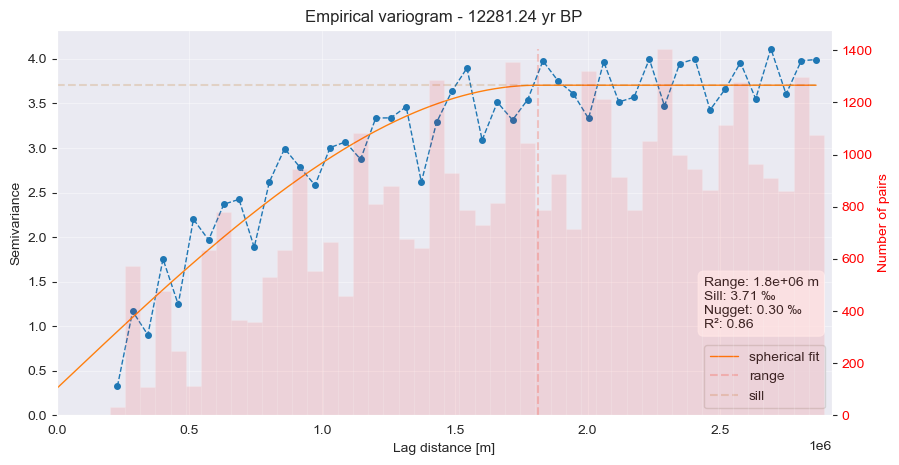

In [43]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='multilinear_lat_prect_elev_dcoast',
                                centers=ref_bins,
                                return_Variogram_object=True,
                                model='spherical')

parameters_dict= gutils.get_vario_parameters_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=True,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params=parameters_dict) #type:ignore
plt.show()